In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


Load dataset

In [3]:
from google.colab import files
uploaded=files.upload()

Saving QVI_purchase_behaviour.csv to QVI_purchase_behaviour.csv
Saving QVI_transaction_data.xlsx to QVI_transaction_data.xlsx


In [9]:
import os
print(os.listdir())

['.config', 'QVI_transaction_data.xlsx', 'QVI_purchase_behaviour.csv', 'sample_data']


In [10]:
print(os.path.exists("Data/QVI_transaction_data.xlsx"))
print(os.path.exists("Data/QVI_purchase_behaviour.csv"))

False
False


In [14]:
import pandas as pd

transactions = pd.read_excel(
    r"QVI_transaction_data.xlsx"
)

customers = pd.read_csv(
    r"QVI_purchase_behaviour.csv"
)

print(transactions.head())
print(customers.head())

    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3       13.8  
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004  

inspect transactions

In [16]:
transactions.shape

(264836, 8)

In [17]:
customers.shape

(72637, 3)

In [18]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [19]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [20]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [21]:
customers.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


check missing values

In [22]:
transactions.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


In [23]:
customers.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


convert date into standard format

In [24]:
transactions['DATE']=pd.to_datetime(transactions['DATE'])
transactions['DATE']

,DATE
0,1970-01-01 00:00:00.000043390
1,1970-01-01 00:00:00.000043599
2,1970-01-01 00:00:00.000043605
3,1970-01-01 00:00:00.000043329
4,1970-01-01 00:00:00.000043330
...,...
264831,1970-01-01 00:00:00.000043533
264832,1970-01-01 00:00:00.000043325
264833,1970-01-01 00:00:00.000043410
264834,1970-01-01 00:00:00.000043461


In [25]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


Exploring product names

In [26]:
transactions['PROD_NAME'].head(20)

,PROD_NAME
0,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g
5,Old El Paso Salsa Dip Tomato Mild 300g
6,Smiths Crinkle Chips Salt & Vinegar 330g
7,Grain Waves Sweet Chilli 210g
8,Doritos Corn Chip Mexican Jalapeno 150g
9,Grain Waves Sour Cream&Chives 210G


remove salsa (other) products keep only chips product

In [29]:
transactions = transactions[
~transactions["PROD_NAME"].str.contains("salsa",case=False)
]

In [30]:
transactions["PROD_NAME"].str.contains("salsa",case=False).sum()

np.int64(0)

check outliers

In [31]:
transactions['PROD_QTY'].describe()

,PROD_QTY
count,246742.000000
mean,1.908062
std,0.659831
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,200.000000


In [32]:
transactions[transactions['PROD_QTY']==200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,1970-01-01 00:00:00.000043331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,1970-01-01 00:00:00.000043605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [33]:
transactions=transactions[
transactions["LYLTY_CARD_NBR"]!=226000
]

Verify Clean dataset

In [34]:
transactions.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,246740,246740.000000,2.467400e+05,2.467400e+05,246740.000000,246740.000000,246740.000000
mean,1970-01-01 00:00:00.000043464,135.050361,1.355303e+05,1.351304e+05,56.352213,1.906456,7.316113
min,1970-01-01 00:00:00.000043282,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.700000
25%,1970-01-01 00:00:00.000043373,70.000000,7.001500e+04,6.756875e+04,26.000000,2.000000,5.800000
50%,1970-01-01 00:00:00.000043464,130.000000,1.303670e+05,1.351815e+05,53.000000,2.000000,7.400000
75%,1970-01-01 00:00:00.000043555,203.000000,2.030832e+05,2.026522e+05,87.000000,2.000000,8.800000
max,1970-01-01 00:00:00.000043646,272.000000,2.373711e+06,2.415841e+06,114.000000,5.000000,29.500000
std,NaN,76.786971,8.071520e+04,7.814760e+04,33.695235,0.342499,2.474897


Daily transactions

In [36]:
daily=transactions.groupby("DATE").size()

<Axes: xlabel='DATE'>

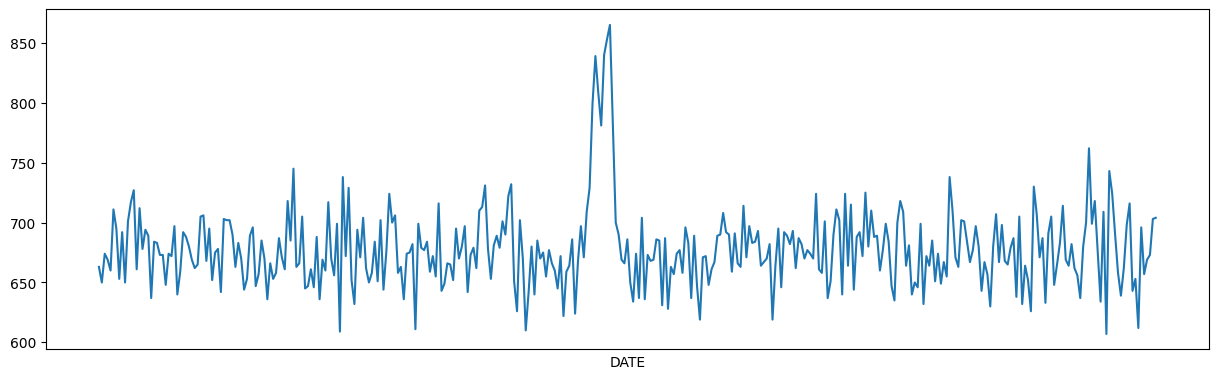

In [37]:
daily.plot(figsize=(15,5))

deriving useful variables

In [38]:
transactions["PACK_SIZE"] = transactions["PROD_NAME"].str.extract(r'(\d+)').astype(int)

In [39]:
transactions["PACK_SIZE"].value_counts()

,count
PACK_SIZE,
175,66390
150,40203
134,25102
110,22387
170,19983
165,15297
330,12540
380,6416
270,6285


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0, 0, '1.0')])

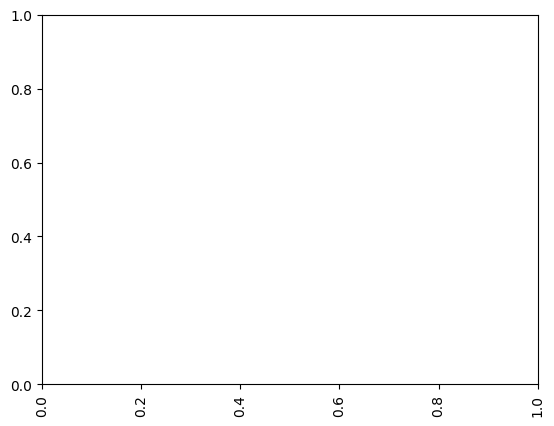

In [40]:
plt.xticks(rotation=90)

Brand Extraction

In [41]:
transactions["BRAND"]=transactions["PROD_NAME"].str.split().str[0]

In [42]:
transactions["BRAND"].value_counts()

,count
BRAND,
Kettle,41288
Smiths,27390
Pringles,25102
Doritos,22041
Thins,14075
RRD,11894
Infuzions,11057
WW,10320
Cobs,9693


Customer dataset analysis

In [43]:
customers.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [44]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [45]:
customers.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [46]:
customers['LIFESTAGE'].value_counts()

,count
LIFESTAGE,
RETIREES,14805
OLDER SINGLES/COUPLES,14609
YOUNG SINGLES/COUPLES,14441
OLDER FAMILIES,9780
YOUNG FAMILIES,9178
MIDAGE SINGLES/COUPLES,7275
NEW FAMILIES,2549


In [47]:
customers['PREMIUM_CUSTOMER'].value_counts()

,count
PREMIUM_CUSTOMER,
Mainstream,29245
Budget,24470
Premium,18922


Merge both tables

In [48]:
data=pd.merge(transactions,customers,on="LYLTY_CARD_NBR", how="left")

In [49]:
data.shape

(246740, 12)

In [50]:
data.isnull().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0
PACK_SIZE,0
BRAND,0


Key metrices

In [51]:
data['TOT_SALES'].sum()

np.float64(1805177.6999999997)

In [52]:
data['LYLTY_CARD_NBR'].nunique()

71287

In [53]:
data['TXN_ID'].nunique()

245255

In [54]:
data['PROD_QTY'].sum()

np.int64(470399)

In [55]:
data['TOT_SALES'].mean()

np.float64(7.3161129123774)

Analyze Total Sales by Customer Segment
**Which customer segments generate the highest chip sales?**

Julia (Category Manager) wants to know:

1.   Who spends the most?
2.   Which customers should be targeted?

3. Which customer groups are most valuable?





In [56]:
sales_segment = (
    data.groupby(["LIFESTAGE", "PREMIUM_CUSTOMER"])["TOT_SALES"]
    .sum()
    .reset_index()
)

sales_segment = sales_segment.sort_values(
    by="TOT_SALES",
    ascending=False
)

sales_segment

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123537.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


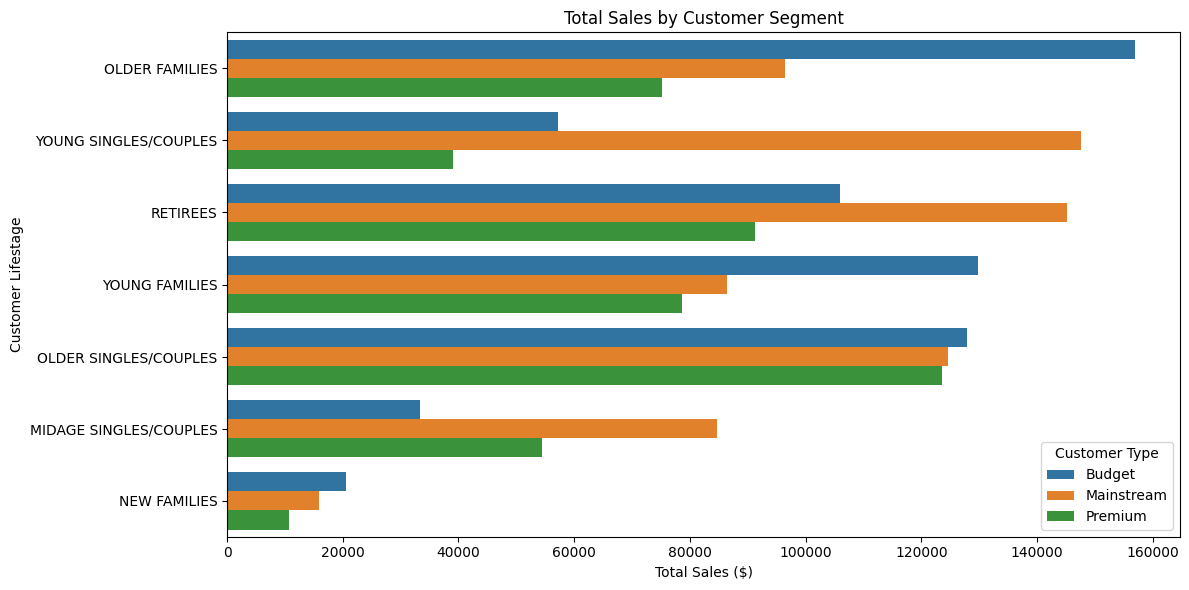

In [57]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=sales_segment,
    x="TOT_SALES",
    y="LIFESTAGE",
    hue="PREMIUM_CUSTOMER"
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Total Sales ($)")
plt.ylabel("Customer Lifestage")
plt.legend(title="Customer Type")

plt.tight_layout()
plt.show()

##Business Insight
Budget Older Families generate the highest chip sales, followed by Mainstream Young Singles/Couples and Mainstream Retirees. These customer groups contribute the largest share of revenue and should be prioritized in marketing campaigns.

##Number of Customers in Each Segment
Are sales high because there are more customers?

In [59]:
customer_segment = (
    data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])
    ["LYLTY_CARD_NBR"]
    .nunique()
    .reset_index(name="Total_Customers")
)

customer_segment

,LIFESTAGE,PREMIUM_CUSTOMER,Total_Customers
0,MIDAGE SINGLES/COUPLES,Budget,1474
1,MIDAGE SINGLES/COUPLES,Mainstream,3298
2,MIDAGE SINGLES/COUPLES,Premium,2369
3,NEW FAMILIES,Budget,1087
4,NEW FAMILIES,Mainstream,830
5,NEW FAMILIES,Premium,575
6,OLDER FAMILIES,Budget,4611
7,OLDER FAMILIES,Mainstream,2788
8,OLDER FAMILIES,Premium,2231
9,OLDER SINGLES/COUPLES,Budget,4849


In [60]:
customer_segment = customer_segment.sort_values(
    by="Total_Customers",
    ascending=False
)

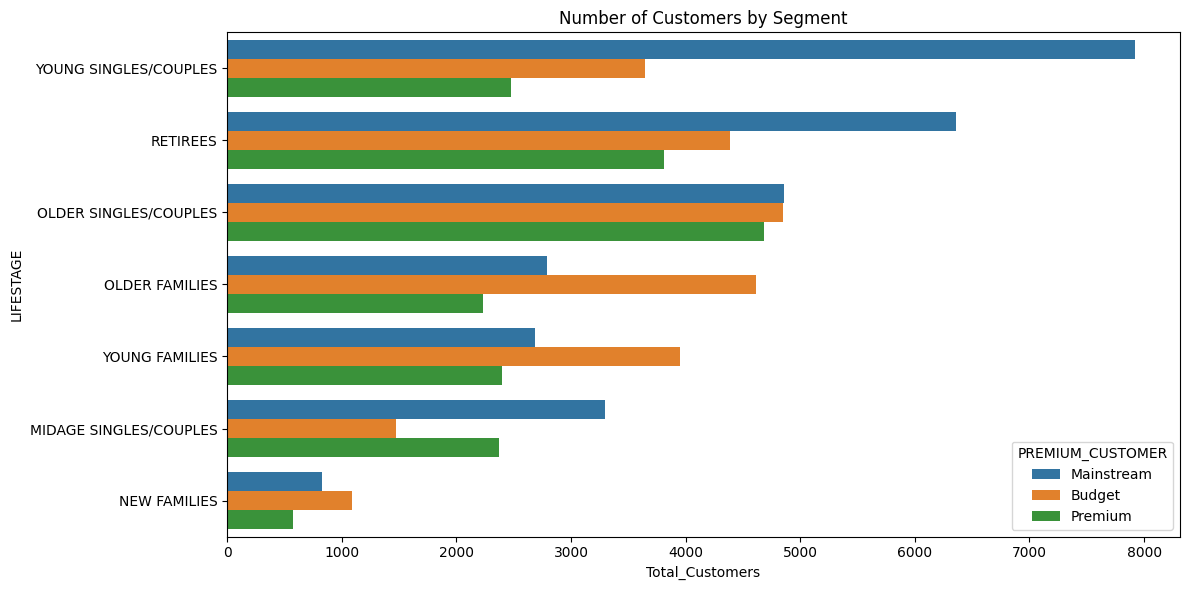

In [61]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=customer_segment,
    x="Total_Customers",
    y="LIFESTAGE",
    hue="PREMIUM_CUSTOMER"
)

plt.title("Number of Customers by Segment")

plt.tight_layout()
plt.show()

##Business Insights
If

Mainstream Young Singles

has many customers,

then

Higher sales are partly due to having more shoppers.

If

Budget Older Families

has relatively fewer customers but very high sales,

then

Each customer spends more.

This distinction is important for marketing strategy.

##Average Chips Purchased Per Customer

In [62]:
units = (
    data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])
    .agg(
        Total_Qty=("PROD_QTY","sum"),
        Customers=("LYLTY_CARD_NBR","nunique")
    )
    .reset_index()
)

units["Avg_Units_Per_Customer"] = (
    units["Total_Qty"]
    /
    units["Customers"]
)

units

,LIFESTAGE,PREMIUM_CUSTOMER,Total_Qty,Customers,Avg_Units_Per_Customer
0,MIDAGE SINGLES/COUPLES,Budget,8883,1474,6.026459
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080
2,MIDAGE SINGLES/COUPLES,Premium,14400,2369,6.078514
3,NEW FAMILIES,Budget,5241,1087,4.821527
4,NEW FAMILIES,Mainstream,4060,830,4.891566
5,NEW FAMILIES,Premium,2769,575,4.815652
6,OLDER FAMILIES,Budget,41853,4611,9.076773
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
8,OLDER FAMILIES,Premium,20239,2231,9.071717
9,OLDER SINGLES/COUPLES,Budget,32883,4849,6.781398


In [63]:
units = units.sort_values(
    by="Avg_Units_Per_Customer",
    ascending=False
)

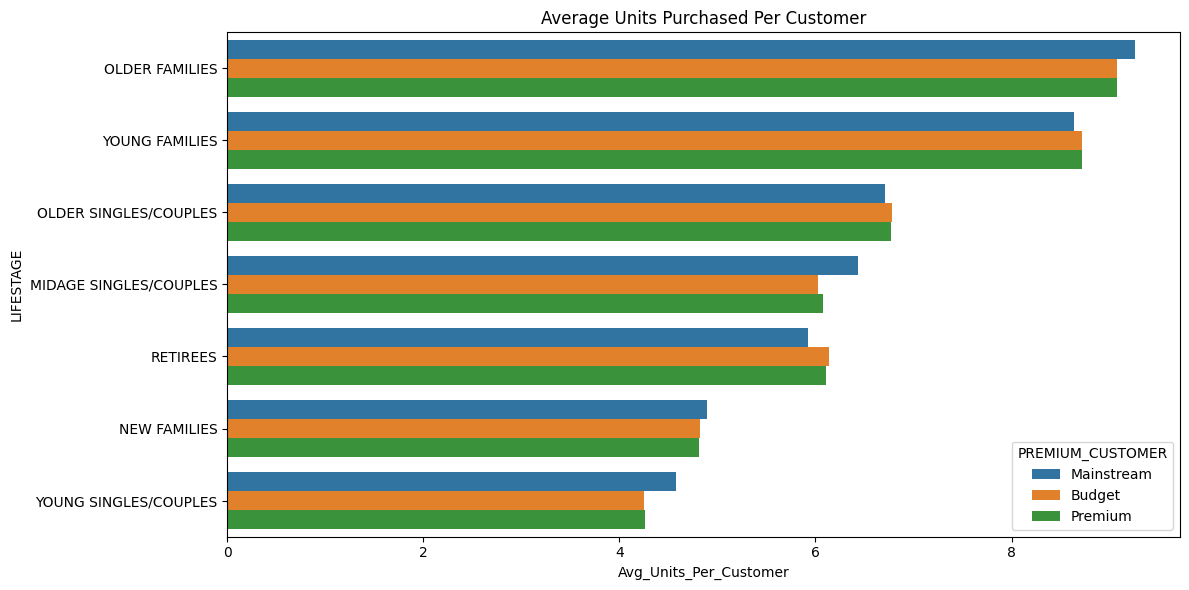

In [64]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=units,
    x="Avg_Units_Per_Customer",
    y="LIFESTAGE",
    hue="PREMIUM_CUSTOMER"
)

plt.title("Average Units Purchased Per Customer")

plt.tight_layout()

plt.show()

##Average Price Paid Per Packet

In [65]:
price = (
    data.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])
    .agg(
        Sales=("TOT_SALES","sum"),
        Quantity=("PROD_QTY","sum")
    )
    .reset_index()
)

price["Avg_Price"] = (
    price["Sales"]
    /
    price["Quantity"]
)

price

,LIFESTAGE,PREMIUM_CUSTOMER,Sales,Quantity,Avg_Price
0,MIDAGE SINGLES/COUPLES,Budget,33345.70,8883,3.753878
1,MIDAGE SINGLES/COUPLES,Mainstream,84734.25,21213,3.994449
2,MIDAGE SINGLES/COUPLES,Premium,54443.85,14400,3.780823
3,NEW FAMILIES,Budget,20607.45,5241,3.931969
4,NEW FAMILIES,Mainstream,15979.70,4060,3.935887
5,NEW FAMILIES,Premium,10760.80,2769,3.886168
6,OLDER FAMILIES,Budget,156863.75,41853,3.747969
7,OLDER FAMILIES,Mainstream,96413.55,25804,3.736380
8,OLDER FAMILIES,Premium,75242.60,20239,3.717703
9,OLDER SINGLES/COUPLES,Budget,127833.60,32883,3.887529


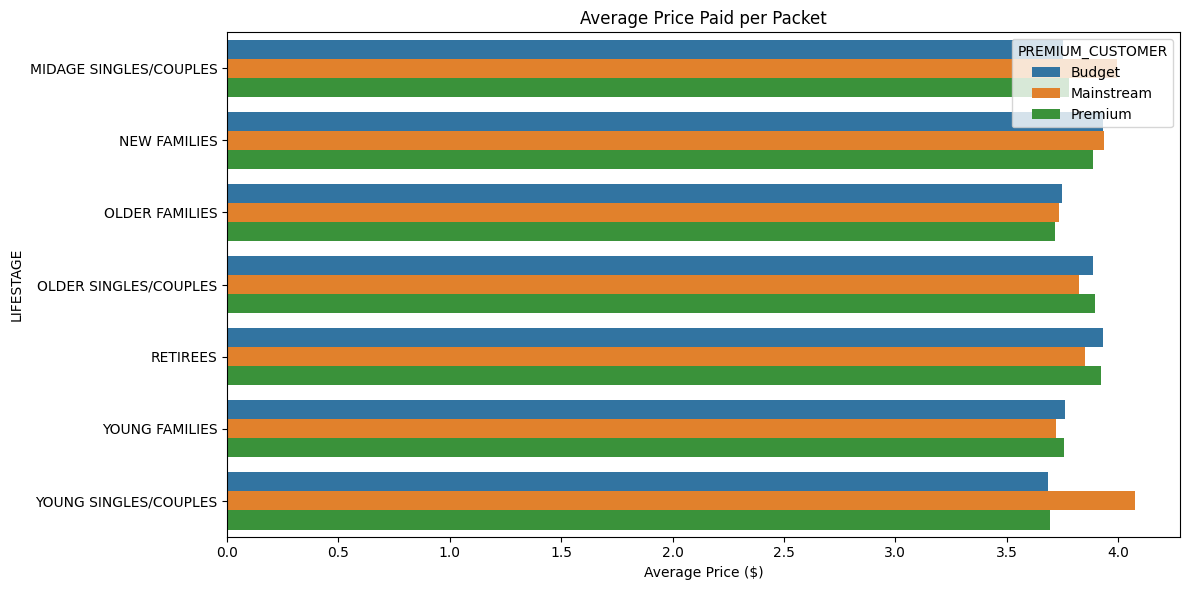

In [66]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=price,
    x="Avg_Price",
    y="LIFESTAGE",
    hue="PREMIUM_CUSTOMER"
)

plt.title("Average Price Paid per Packet")

plt.xlabel("Average Price ($)")

plt.tight_layout()

plt.show()

In [69]:
sales_segment.to_csv("Cleaned_Data/sales_segment.csv", index=False)
customer_segment.to_csv("Cleaned_Data/customer_segment.csv", index=False)
units.to_csv("Cleaned_Data/average_units.csv", index=False)
price.to_csv("Cleaned_Data/average_price.csv", index=False)

##Brand preferance analysis

In [70]:
brand_sales = (
    data.groupby("BRAND")
    .agg(
        Total_Sales=("TOT_SALES","sum"),
        Total_Qty=("PROD_QTY","sum"),
        Transactions=("TXN_ID","count")
    )
    .reset_index()
)

brand_sales = brand_sales.sort_values(
    by="Total_Sales",
    ascending=False
)

brand_sales.head(10)

,BRAND,Total_Sales,Total_Qty,Transactions
12,Kettle,390239.8,79051,41288
19,Smiths,202908.6,51973,27390
6,Doritos,187277.9,42222,22041
15,Pringles,177655.5,48019,25102
22,Thins,88852.5,26929,14075
24,Twisties,81522.1,18118,9454
23,Tostitos,79789.6,18134,9471
10,Infuzions,76247.6,21119,11057
4,Cobs,70569.8,18571,9693
16,RRD,64954.5,22500,11894


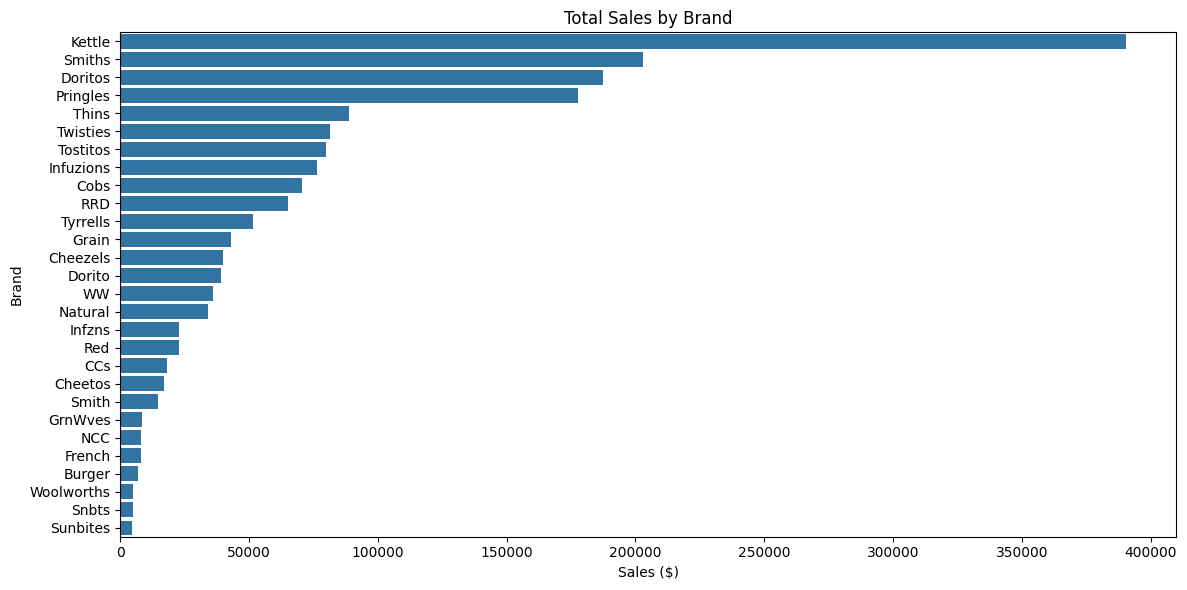

In [71]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_sales,
    x="Total_Sales",
    y="BRAND"
)

plt.title("Total Sales by Brand")
plt.xlabel("Sales ($)")
plt.ylabel("Brand")

plt.tight_layout()
plt.show()

##Business insights
Kettle, Smiths and Doritos contribute the highest overall chip sales, indicating these brands dominate customer purchases and should remain key focus products.

##Preferred Brands of the Target Segment

In [72]:
target_segment = data[
    (data["LIFESTAGE"]=="YOUNG SINGLES/COUPLES") &
    (data["PREMIUM_CUSTOMER"]=="Mainstream")
]

In [73]:
target_segment.shape

(19544, 12)

In [74]:
target_brand = (
    target_segment.groupby("BRAND")
    .agg(
        Transactions=("TXN_ID","count"),
        Sales=("TOT_SALES","sum")
    )
    .reset_index()
)

target_brand = target_brand.sort_values(
    by="Transactions",
    ascending=False
)

target_brand

,BRAND,Transactions,Sales
12,Kettle,3844,35423.6
15,Pringles,2315,16006.2
6,Doritos,2076,17266.4
19,Smiths,1790,14337.5
22,Thins,1166,7217.1
10,Infuzions,962,6693.6
24,Twisties,900,7539.8
23,Tostitos,890,7238.0
4,Cobs,864,6144.6
16,RRD,639,3357.0


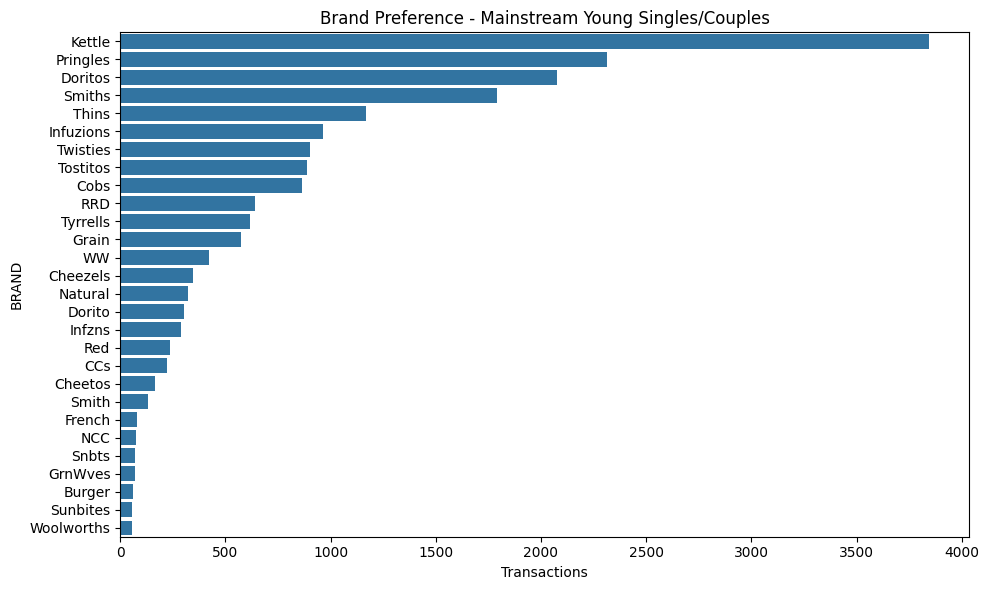

In [75]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=target_brand,
    x="Transactions",
    y="BRAND"
)

plt.title("Brand Preference - Mainstream Young Singles/Couples")

plt.tight_layout()

plt.show()

##Compare Brand Affinity with Other Customers

In [76]:
target_share = (
    target_segment["BRAND"]
    .value_counts(normalize=True)
    .reset_index()
)

target_share.columns = ["BRAND","Target_Percentage"]

In [77]:
others = data[
~(
(data["LIFESTAGE"]=="YOUNG SINGLES/COUPLES") &
(data["PREMIUM_CUSTOMER"]=="Mainstream")
)
]

In [78]:
other_share = (
    others["BRAND"]
    .value_counts(normalize=True)
    .reset_index()
)

other_share.columns=["BRAND","Other_Percentage"]

In [79]:
brand_compare = pd.merge(
    target_share,
    other_share,
    on="BRAND"
)

In [80]:
brand_compare["Affinity"] = (
    brand_compare["Target_Percentage"]
    /
    brand_compare["Other_Percentage"]
)

In [81]:
brand_compare = brand_compare.sort_values(
    by="Affinity",
    ascending=False
)

brand_compare.head(10)

,BRAND,Target_Percentage,Other_Percentage,Affinity
10,Tyrrells,0.031672,0.025630,1.235751
6,Twisties,0.046050,0.037650,1.223096
15,Dorito,0.015503,0.012676,1.223031
2,Doritos,0.106222,0.087876,1.208774
7,Tostitos,0.045538,0.037769,1.205700
0,Kettle,0.196684,0.164809,1.193406
1,Pringles,0.118451,0.100297,1.181003
11,Grain,0.029472,0.025071,1.175546
16,Infzns,0.014736,0.012571,1.172253
8,Cobs,0.044208,0.038861,1.137600


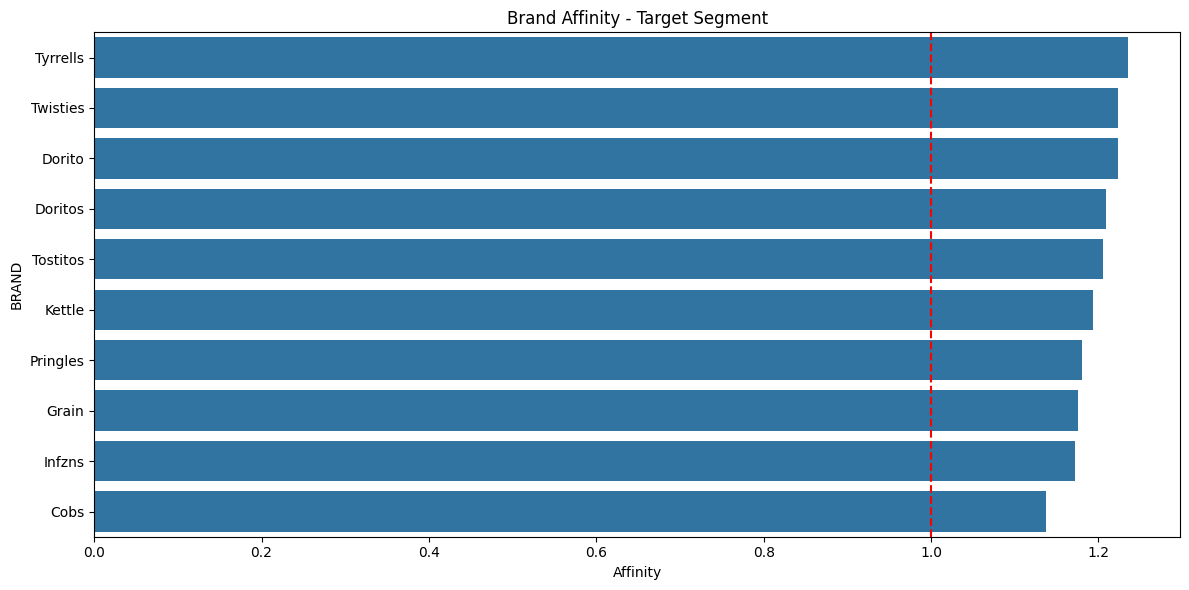

In [82]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=brand_compare.head(10),
    x="Affinity",
    y="BRAND"
)

plt.axvline(1,color="red",linestyle="--")

plt.title("Brand Affinity - Target Segment")

plt.tight_layout()

plt.show()

##Business insights
Affinity scores above 1 indicate brands that resonate particularly well with Mainstream Young Singles/Couples. These brands should receive targeted promotions, shelf placement, and digital marketing for this customer segment.

##Save results

In [83]:
brand_sales.to_csv(
    "Cleaned_Data/brand_sales.csv",
    index=False
)

target_brand.to_csv(
    "Cleaned_Data/target_brand.csv",
    index=False
)

brand_compare.to_csv(
    "Cleaned_Data/brand_affinity.csv",
    index=False
)

##Pack Size Preference Analysis
Do Mainstream Young Singles/Couples prefer particular pack sizes compared to the rest of the customers?

In [84]:
pack_sales = (
    data.groupby("PACK_SIZE")
    .agg(
        Transactions=("TXN_ID", "count"),
        Total_Sales=("TOT_SALES", "sum"),
        Quantity=("PROD_QTY", "sum")
    )
    .reset_index()
)

pack_sales = pack_sales.sort_values("PACK_SIZE")

pack_sales

,PACK_SIZE,Transactions,Total_Sales,Quantity
0,70,1507,6852.0,2855
1,90,3008,9676.4,5692
2,110,22387,162765.4,42835
3,125,1454,5733.0,2730
4,134,25102,177655.5,48019
5,135,3257,26090.4,6212
6,150,40203,289681.8,76662
7,160,2970,10647.6,5604
8,165,15297,101360.6,29051
9,170,19983,146673.0,38088


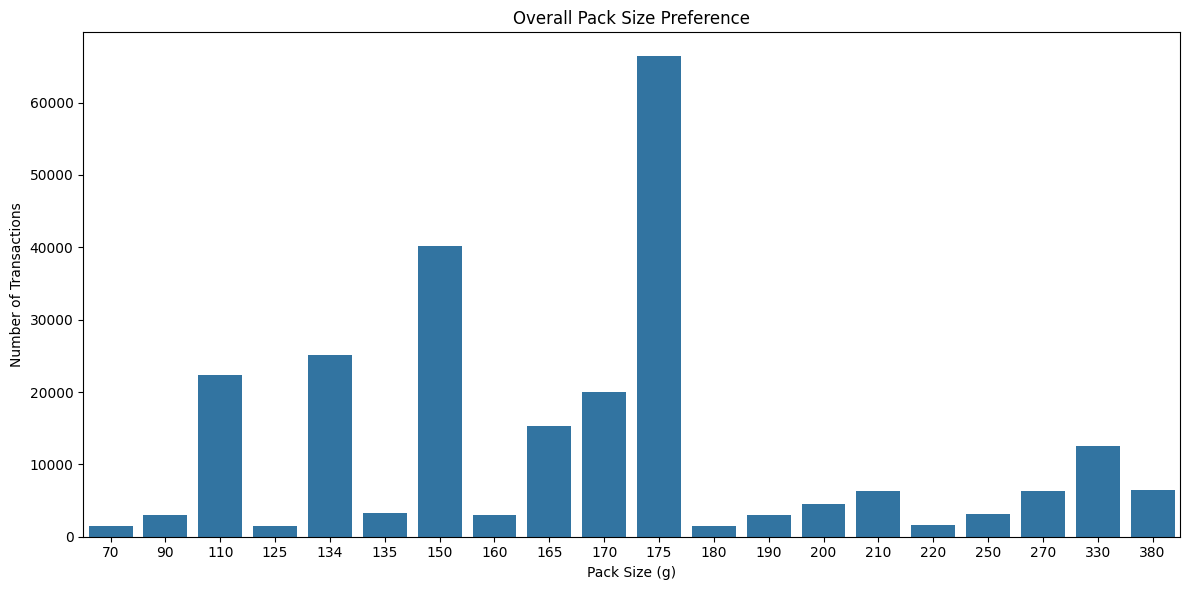

In [85]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=pack_sales,
    x="PACK_SIZE",
    y="Transactions"
)

plt.title("Overall Pack Size Preference")
plt.xlabel("Pack Size (g)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

##Pack Size Preference of Target Segment

In [87]:
target_pack = (
    target_segment["PACK_SIZE"]
    .value_counts(normalize=True)
    .reset_index()
)

target_pack.columns = ["PACK_SIZE", "Target_Percentage"]

target_pack

,PACK_SIZE,Target_Percentage
0,175,0.255679
1,150,0.157593
2,134,0.118451
3,110,0.104943
4,170,0.080587
5,330,0.061144
6,165,0.056386
7,380,0.032030
8,270,0.031723
9,210,0.029472


In [88]:
other_pack = (
    others["PACK_SIZE"]
    .value_counts(normalize=True)
    .reset_index()
)

other_pack.columns = ["PACK_SIZE", "Other_Percentage"]

In [89]:
pack_compare = pd.merge(
    target_pack,
    other_pack,
    on="PACK_SIZE"
)

pack_compare["Affinity"] = (
    pack_compare["Target_Percentage"] /
    pack_compare["Other_Percentage"]
)

pack_compare = pack_compare.sort_values(
    by="Affinity",
    ascending=False
)

pack_compare

,PACK_SIZE,Target_Percentage,Other_Percentage,Affinity
8,270,0.031723,0.024934,1.272269
7,380,0.032030,0.025485,1.256849
5,330,0.061144,0.049935,1.224477
2,134,0.118451,0.100297,1.181003
9,210,0.029472,0.025071,1.175546
3,110,0.104943,0.089509,1.172431
10,135,0.014838,0.013059,1.136234
11,250,0.014327,0.012716,1.126673
4,170,0.080587,0.081023,0.994629
1,150,0.157593,0.163396,0.964484


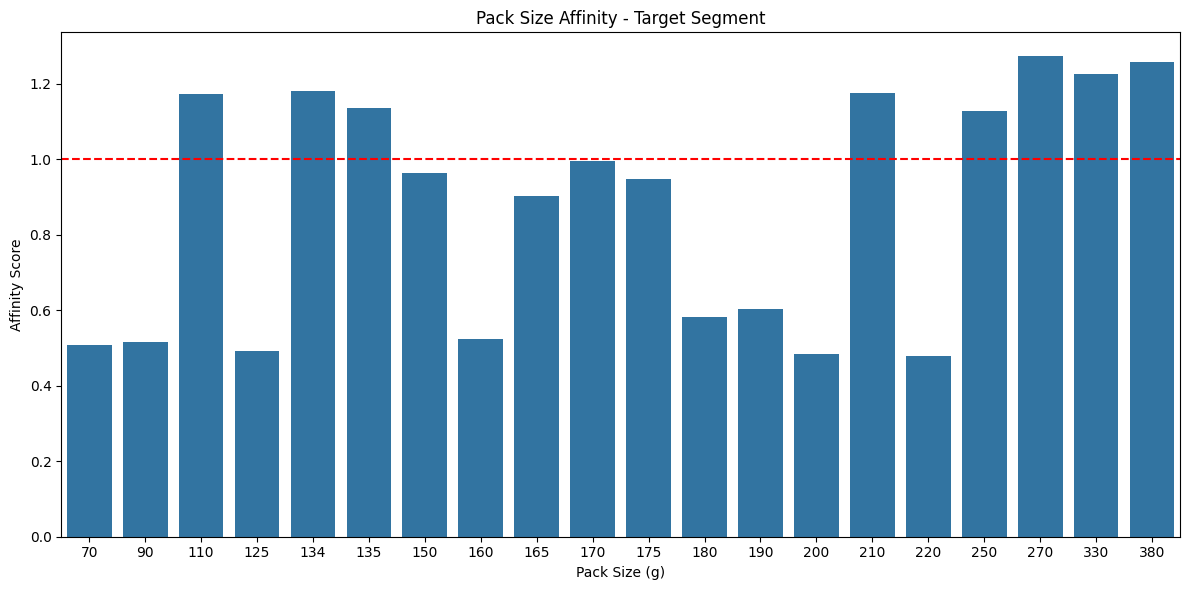

In [90]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=pack_compare,
    x="PACK_SIZE",
    y="Affinity"
)

plt.axhline(1, color="red", linestyle="--")

plt.title("Pack Size Affinity - Target Segment")
plt.xlabel("Pack Size (g)")
plt.ylabel("Affinity Score")

plt.tight_layout()
plt.show()

##Statistical Significance Test (t-test)
Objective

The template asks you to verify whether Mainstream Young & Mid-age Singles/Couples pay significantly more per packet than Budget or Premium customers.

In [91]:
data["UNIT_PRICE"] = data["TOT_SALES"] / data["PROD_QTY"]

In [92]:
mainstream = data[
    (
        data["LIFESTAGE"].isin([
            "YOUNG SINGLES/COUPLES",
            "MIDAGE SINGLES/COUPLES"
        ])
    )
    &
    (data["PREMIUM_CUSTOMER"] == "Mainstream")
]["UNIT_PRICE"]

In [93]:
others_price = data[
    (
        data["LIFESTAGE"].isin([
            "YOUNG SINGLES/COUPLES",
            "MIDAGE SINGLES/COUPLES"
        ])
    )
    &
    (data["PREMIUM_CUSTOMER"] != "Mainstream")
]["UNIT_PRICE"]

In [94]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    mainstream,
    others_price,
    equal_var=False
)

print("T Statistic :", t_stat)
print("P-value :", p_value)

T Statistic : 37.6243885962295
P-value : 6.967354233018139e-306


##Final Business Recommendations
Recommendation 1

Target Mainstream Young Singles/Couples because they are one of the highest revenue-generating customer segments and show strong brand loyalty.

Recommendation 2

Continue promoting popular brands such as Kettle, Doritos, and Smiths, especially among high-value customer groups.

Recommendation 3

Stock more of the pack sizes most preferred by target customers to improve availability and reduce lost sales.

Recommendation 4

Offer family bundle promotions for Older Families, who tend to purchase larger quantities of chips.

Recommendation 5

Maintain premium-priced products for customer groups that demonstrate a willingness to pay higher prices rather than relying only on discounts.

In [95]:
data.to_csv(
    "Cleaned_Data/final_merged_data.csv",
    index=False
)

pack_compare.to_csv(
    "Cleaned_Data/pack_affinity.csv",
    index=False
)

pack_sales.to_csv(
    "Cleaned_Data/pack_sales.csv",
    index=False
)

In [98]:
import os

os.makedirs("Cleaned_Data", exist_ok=True)

In [99]:
transactions.to_csv(
    "Cleaned_Data/transaction_clean.csv",
    index=False
)

In [100]:
customers.to_csv(
    "Cleaned_Data/customer_clean.csv",
    index=False
)

In [101]:
data.to_csv(
    "Cleaned_Data/final_merged_data.csv",
    index=False
)

In [102]:
sales_segment

,LIFESTAGE,PREMIUM_CUSTOMER,TOT_SALES
6,OLDER FAMILIES,Budget,156863.75
19,YOUNG SINGLES/COUPLES,Mainstream,147582.20
13,RETIREES,Mainstream,145168.95
15,YOUNG FAMILIES,Budget,129717.95
9,OLDER SINGLES/COUPLES,Budget,127833.60
10,OLDER SINGLES/COUPLES,Mainstream,124648.50
11,OLDER SINGLES/COUPLES,Premium,123537.55
12,RETIREES,Budget,105916.30
7,OLDER FAMILIES,Mainstream,96413.55
14,RETIREES,Premium,91296.65


In [103]:
sales_segment.to_csv(
    "Cleaned_Data/sales_segment.csv",
    index=False
)

In [104]:
customer_segment

,LIFESTAGE,PREMIUM_CUSTOMER,Total_Customers
19,YOUNG SINGLES/COUPLES,Mainstream,7917
13,RETIREES,Mainstream,6358
10,OLDER SINGLES/COUPLES,Mainstream,4858
9,OLDER SINGLES/COUPLES,Budget,4849
11,OLDER SINGLES/COUPLES,Premium,4682
6,OLDER FAMILIES,Budget,4611
12,RETIREES,Budget,4385
15,YOUNG FAMILIES,Budget,3953
14,RETIREES,Premium,3812
18,YOUNG SINGLES/COUPLES,Budget,3647


In [105]:
customer_segment.to_csv(
    "Cleaned_Data/customer_segment.csv",
    index=False
)

In [106]:
units

,LIFESTAGE,PREMIUM_CUSTOMER,Total_Qty,Customers,Avg_Units_Per_Customer
7,OLDER FAMILIES,Mainstream,25804,2788,9.255380
6,OLDER FAMILIES,Budget,41853,4611,9.076773
8,OLDER FAMILIES,Premium,20239,2231,9.071717
15,YOUNG FAMILIES,Budget,34482,3953,8.722995
17,YOUNG FAMILIES,Premium,20901,2398,8.716013
16,YOUNG FAMILIES,Mainstream,23194,2685,8.638361
9,OLDER SINGLES/COUPLES,Budget,32883,4849,6.781398
11,OLDER SINGLES/COUPLES,Premium,31695,4682,6.769543
10,OLDER SINGLES/COUPLES,Mainstream,32607,4858,6.712021
1,MIDAGE SINGLES/COUPLES,Mainstream,21213,3298,6.432080


In [107]:
units.to_csv(
    "Cleaned_Data/average_units.csv",
    index=False
)

In [108]:
price.to_csv(
    "Cleaned_Data/average_price.csv",
    index=False
)

In [109]:
brand_sales.to_csv(
    "Cleaned_Data/brand_sales.csv",
    index=False
)

In [110]:
brand_compare.to_csv(
    "Cleaned_Data/brand_affinity.csv",
    index=False
)

In [111]:
pack_sales.to_csv(
    "Cleaned_Data/pack_sales.csv",
    index=False
)

In [112]:
pack_compare.to_csv(
    "Cleaned_Data/pack_affinity.csv",
    index=False
)

In [113]:
import os

print(os.listdir("Cleaned_Data"))

['sales_segment.csv', 'transaction_clean.csv', 'pack_sales.csv', 'pack_affinity.csv', 'customer_segment.csv', 'brand_affinity.csv', 'customer_clean.csv', 'target_brand.csv', 'average_units.csv', 'average_price.csv', 'brand_sales.csv', 'final_merged_data.csv']


In [115]:
import os

print(os.listdir("/content"))

['.config', 'Cleaned_Data', 'QVI_transaction_data.xlsx', 'QVI_purchase_behaviour.csv', 'sample_data']


In [116]:
print(os.listdir("/content/Cleaned_Data"))

['sales_segment.csv', 'transaction_clean.csv', 'pack_sales.csv', 'pack_affinity.csv', 'customer_segment.csv', 'brand_affinity.csv', 'customer_clean.csv', 'target_brand.csv', 'average_units.csv', 'average_price.csv', 'brand_sales.csv', 'final_merged_data.csv']


In [117]:
from google.colab import files

files.download("/content/Cleaned_Data/final_merged_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [118]:
import os

os.makedirs("/content/Cleaned_Data", exist_ok=True)

sales_segment.to_csv("/content/Cleaned_Data/sales_segment.csv", index=False)

print(os.listdir("/content/Cleaned_Data"))

['sales_segment.csv', 'transaction_clean.csv', 'pack_sales.csv', 'pack_affinity.csv', 'customer_segment.csv', 'brand_affinity.csv', 'customer_clean.csv', 'target_brand.csv', 'average_units.csv', 'average_price.csv', 'brand_sales.csv', 'final_merged_data.csv']


In [119]:
import os

print(os.listdir("/content"))

['.config', 'Cleaned_Data', 'QVI_transaction_data.xlsx', 'QVI_purchase_behaviour.csv', 'sample_data']


In [120]:
print(os.listdir("/content/Cleaned_Data"))

['sales_segment.csv', 'transaction_clean.csv', 'pack_sales.csv', 'pack_affinity.csv', 'customer_segment.csv', 'brand_affinity.csv', 'customer_clean.csv', 'target_brand.csv', 'average_units.csv', 'average_price.csv', 'brand_sales.csv', 'final_merged_data.csv']


In [126]:
!zip -r Cleaned_Data.zip /content/Cleaned_Data

  adding: content/Cleaned_Data/ (stored 0%)
  adding: content/Cleaned_Data/sales_segment.csv (deflated 61%)
  adding: content/Cleaned_Data/transaction_clean.csv (deflated 90%)
  adding: content/Cleaned_Data/pack_sales.csv (deflated 41%)
  adding: content/Cleaned_Data/pack_affinity.csv (deflated 49%)
  adding: content/Cleaned_Data/customer_segment.csv (deflated 65%)
  adding: content/Cleaned_Data/brand_affinity.csv (deflated 46%)
  adding: content/Cleaned_Data/customer_clean.csv (deflated 88%)
  adding: content/Cleaned_Data/target_brand.csv (deflated 40%)
  adding: content/Cleaned_Data/average_units.csv (deflated 55%)
  adding: content/Cleaned_Data/average_price.csv (deflated 55%)
  adding: content/Cleaned_Data/brand_sales.csv (deflated 38%)
  adding: content/Cleaned_Data/final_merged_data.csv (deflated 92%)


In [127]:
from google.colab import files

files.download("Cleaned_Data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>